# EN3160: Image Processing and Machine Vision
## Assignment 1: Intensity Transformations and Neighborhood Filtering

**Department of Electronic and Telecommunication Engineering, University of Moratuwa**

* **Name:** M.R.A.Hakam
* **Index Number:** 230224V
* **GitHub Repository:** [https://github.com/hakammra/EN3160-Assignment-01](https://github.com/hakammra/EN3160-Assignment-01)
* **Date:** 14th September 2026

In [1]:
from pathlib import Path
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_dir = Path('Images/assignment')
if not img_dir.exists():
    img_dir = Path('../Images/assignment')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['image.cmap'] = 'gray'

## 1. Piecewise linear intensity transformation

### Given transformation

The first part is to reproduce the curve in Fig. 1a. The curve is represented by its breakpoints and converted into a 256 value lookup table. The repeated input values at 50 and 150 are intentional because the graph has vertical jumps at those positions. Each output pixel depends only on the corresponding input value,

$$g(x,y)=T(f(x,y)).$$

For an ordinary section between two different input breakpoints, the straight line value is

$$T(r)=s_k+\frac{s_{k+1}-s_k}{r_{k+1}-r_k}(r-r_k).$$

After the 256 values are prepared, the final image is obtained using the notation $g=t[f]$.

I changed the breakpoints to make a smoother curve that brightens the face without creating the strong tonal jumps seen in the given transformation. Both curves and all three images are displayed together for comparison.


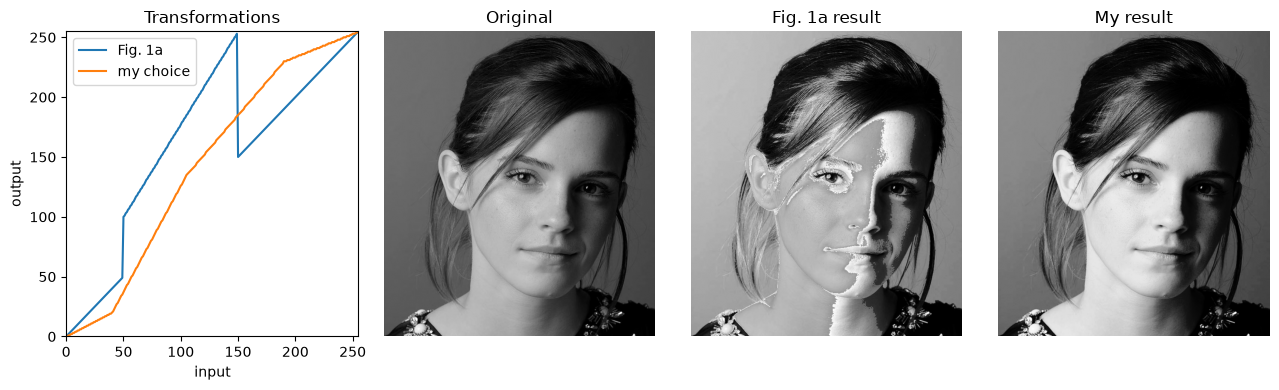

In [2]:
def intensity_transform(im, breakpoints):
    bp = np.asarray(breakpoints, dtype=int)

    t = np.zeros(256, dtype=float)
    for (r0, s0), (r1, s1) in zip(bp[:-1], bp[1:]):
        if r1 == r0:
            t[r0] = s1
        else:
            t[r0:r1 + 1] = np.linspace(s0, s1, r1 - r0 + 1)

    t = np.clip(t, 0, 255).astype(np.uint8)
    return t[im], t

im1 = cv.imread(str(img_dir / 'q1_emma.jpeg'), cv.IMREAD_GRAYSCALE)
bp_given = [[0, 0], [50, 50], [50, 100], [150, 255], [150, 150], [255, 255]]
bp_mine = [[0, 0], [40, 20], [105, 135], [190, 230], [255, 255]]

g1, t1 = intensity_transform(im1, bp_given)
g2, t2 = intensity_transform(im1, bp_mine)

fig, ax = plt.subplots(1, 4, figsize=(13, 4))
ax[0].plot(t1, label='Fig. 1a')
ax[0].plot(t2, label='my choice')
ax[0].set(xlim=(0, 255), ylim=(0, 255), xlabel='input', ylabel='output', title='Transformations')
ax[0].legend()
for a, im, title in zip(ax[1:], [im1, g1, g2], ['Original', 'Fig. 1a result', 'My result']):
    a.imshow(im, vmin=0, vmax=255)
    a.set_title(title)
    a.axis('off')
plt.tight_layout()
plt.show()

### Comparison of the two transformations

The given curve produces the expected sudden brightness changes. They are specially visible across the forehead, nose, and cheek because neighboring input levels can be sent to very different outputs. This result is useful for confirming that the two discontinuities were implemented but it is not visually pleasing.

My curve has no discontinuities. It darkens few low values, increases the slope through the facial midtones, and gradually compresses the brightest values. The improvement is intentionally modest. A stronger curve made the skin too bright and removed small highlight differences. The selected breakpoints give a clearer face while keeping the hair and background dark.

## 2. White-matter and gray-matter accentuation

This question uses the same lookup table function as Question 1, but the curve acts like an intensity window.

### (a) White matter

In this proton density image white matter appears slightly darker than gray matter. I used a lower intensity window, approximately 145 to 175, and mapped that region to high output values. Values outside the selected range are kept dark instead of completely removing.

### (b) Gray matter

For gray matter I moved the window upward, approximately from 175 to 205. Plotting both transformations is useful because the selected ranges overlap slightly withi=out forming a perfect separation.

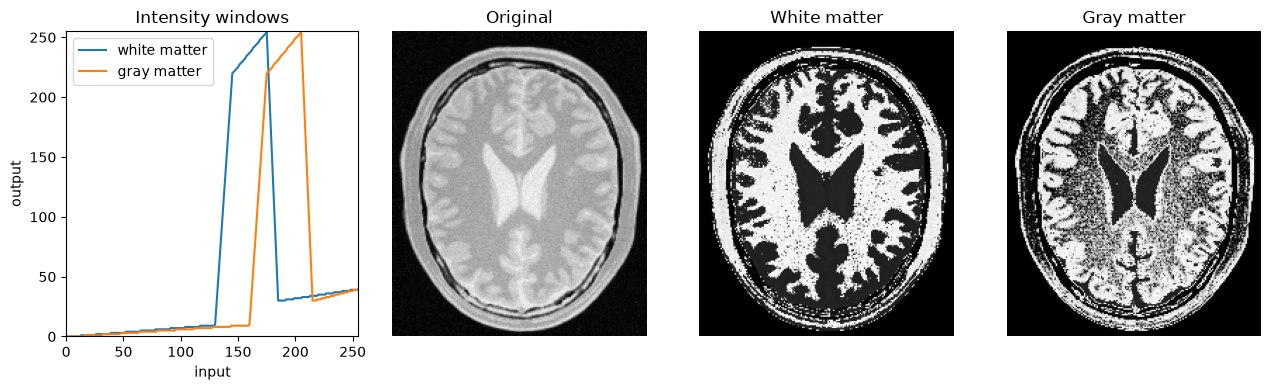

In [3]:
im2 = cv.imread(str(img_dir / 'q2_brain.png'), cv.IMREAD_GRAYSCALE)

bp_wm = [[0, 0], [130, 10], [145, 220], [175, 255], [185, 30], [255, 40]]
bp_gm = [[0, 0], [160, 10], [175, 220], [205, 255], [215, 30], [255, 40]]
wm, t_wm = intensity_transform(im2, bp_wm)
gm, t_gm = intensity_transform(im2, bp_gm)

fig, ax = plt.subplots(1, 4, figsize=(13, 4))
ax[0].plot(t_wm, label='white matter')
ax[0].plot(t_gm, label='gray matter')
ax[0].set(xlim=(0, 255), ylim=(0, 255), xlabel='input', ylabel='output', title='Intensity windows')
ax[0].legend()
for a, im, title in zip(ax[1:], [im2, wm, gm], ['Original', 'White matter', 'Gray matter']):
    a.imshow(im, vmin=0, vmax=255)
    a.set_title(title)
    a.axis('off')
plt.tight_layout()
plt.show()

### Ouputs

The two outputs show that intensity slicing accentuates a range rather than identifying tissue perfectly. The white matter setting gives stronger output in the darker inner parts surrounding the ventricles. The gray matter setting emphasizes more of the brighter folded region close to outside of the brain.

Some skull and boundary pixels also become bright because they share similar grayscale values with the selected tissue. This is a limitation of using only a point transformation as it has no information about pixel position or anatomical structure. The overlapping ranges also explain why a few regions appear in both results. Even with the limitation the two plots make the difference between the chosen windows clear.

## 3. Gamma correction in $L^*a^*b^*$

### (a) Correction of the $L$ plane

The BGR image is converted to $L^*a^*b^*$ and split into three planes. Power law transformation is apllied only to $L$ using

$$L_{out}=255\left(\frac{L_{in}}{255}\right)^{\gamma}.$$

Then its mergd with the original $a$ and $b$ planes. I tried values below 1 and selected $\gamma=0.65$ because it reveals the dark rocks without making the white dress excessively bright.

### (b) Histograms

The original and corrected $L$ histograms are shown below the images. Lightness histograms is used because this is the plane that is actually transformed.

gamma = 0.65
mean L: 71.26 -> 98.60


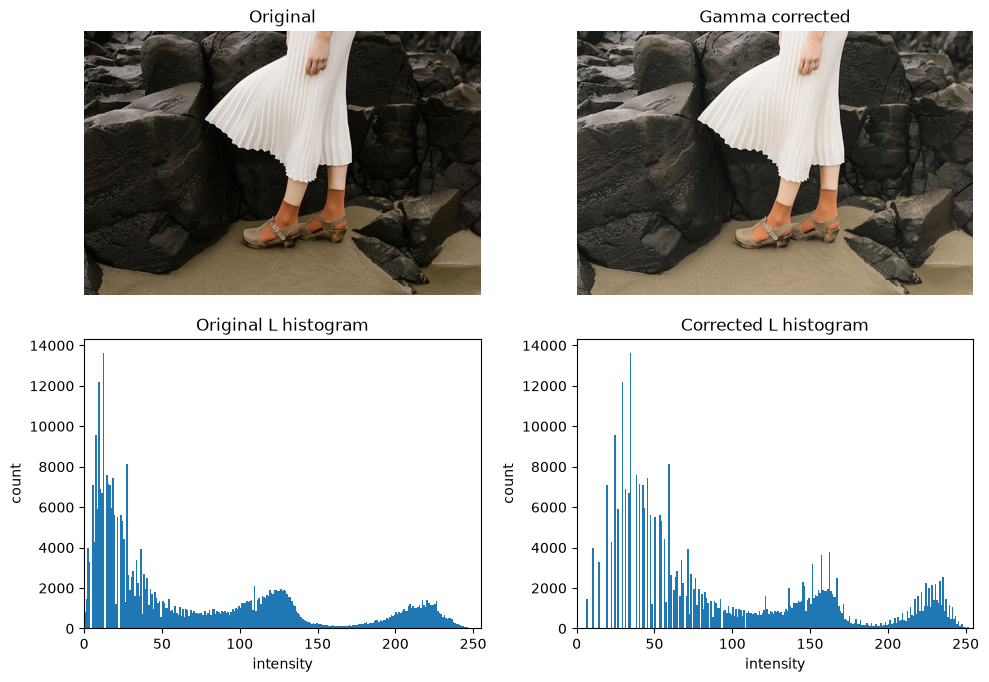

In [4]:
im3_bgr = cv.imread(str(img_dir / 'q3_gamma.jpeg'))
lab = cv.cvtColor(im3_bgr, cv.COLOR_BGR2LAB)
L, a_plane, b_plane = cv.split(lab)

gamma = 0.65
t_gamma = np.array([(i / 255.0) ** gamma * 255 for i in range(256)], dtype=np.uint8)
L2 = t_gamma[L]
out3 = cv.cvtColor(cv.merge([L2, a_plane, b_plane]), cv.COLOR_LAB2RGB)
im3 = cv.cvtColor(im3_bgr, cv.COLOR_BGR2RGB)

print(f'gamma = {gamma}')
print(f'mean L: {L.mean():.2f} -> {L2.mean():.2f}')

fig, ax = plt.subplots(2, 2, figsize=(10, 7))
ax[0, 0].imshow(im3); ax[0, 0].set_title('Original'); ax[0, 0].axis('off')
ax[0, 1].imshow(out3); ax[0, 1].set_title('Gamma corrected'); ax[0, 1].axis('off')
ax[1, 0].hist(L.ravel(), bins=256, range=(0, 256)); ax[1, 0].set_title('Original L histogram')
ax[1, 1].hist(L2.ravel(), bins=256, range=(0, 256)); ax[1, 1].set_title('Corrected L histogram')
for a in ax[1]:
    a.set(xlim=(0, 255), xlabel='intensity', ylabel='count')
plt.tight_layout()
plt.show()

### Selected $\gamma$ and histogram comparison
With $\gamma=0.65$, the mean $L$ value increases from 71.26 to 98.60. The corrected histogram shifts many dark pixels toward the middle while the high intensity group remains below 255. Texture becomes clearer in the black rocks and the darker parts of the clothing.

The correction is applied only to $L$, so the $a$ and $b$ values are unchanged before conversion back to RGB. This avoids independently changing the three color channels. A smaller gamma value brightened the shadows more, but the result started to look washed out. The selected value is between recovering shadow detail and keeping the scene real.

## 4. Vibrance using the saturation plane

### (a) HSV planes

The image is converted from BGR to HSV and the hue, saturation, and value planes are shown separately in grayscale.

### (b) and (c) Saturation transformation

The applied function given in the question to the saturation plane is,

$$S_{out}=\min\left(S_{in}+a\,128\exp\left[-\frac{(S_{in}-128)^2}{2\sigma^2}\right],255\right).$$

I used $\sigma=70$. After comparing several strengths visually, I selected $a=0.7$.

### (d) Recombination

The changed saturation plane is merged with the unchanged hue and value planes and converted back to RGB.

### (e) Display

The final figure includes the three HSV planes, the transformation curve, and the original and enhanced images.

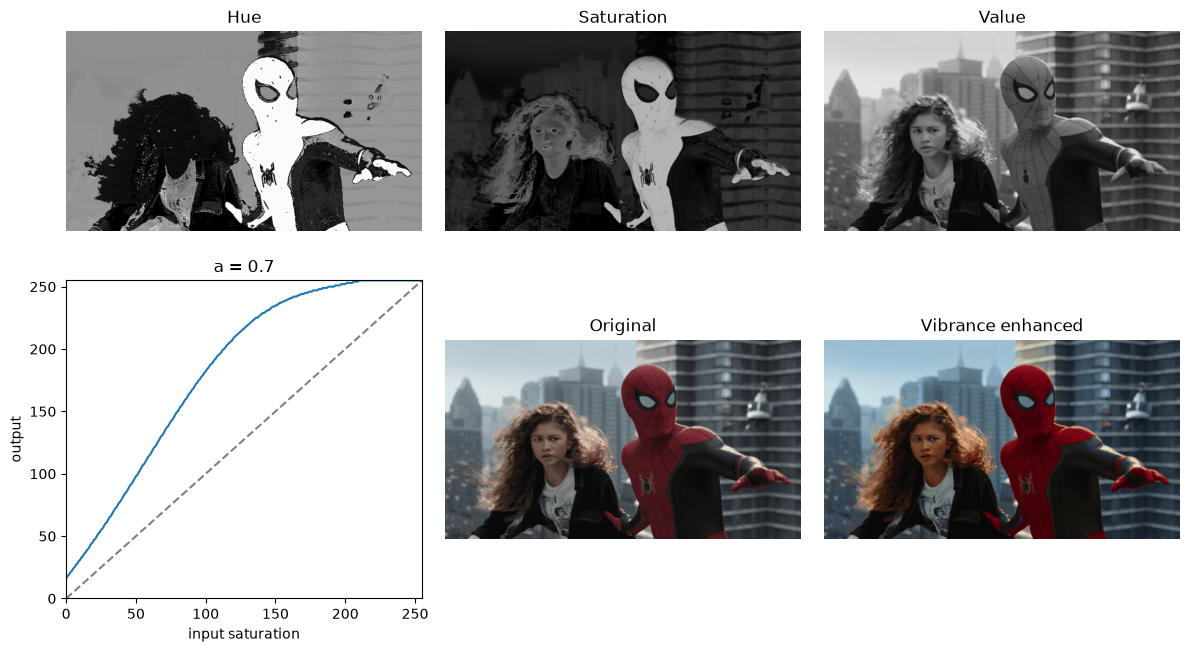

In [5]:
im4_bgr = cv.imread(str(img_dir / 'q4_vibrance.png'))
h4, s4, v4 = cv.split(cv.cvtColor(im4_bgr, cv.COLOR_BGR2HSV))

a_value = 0.7
sigma = 70.0
x = np.arange(256, dtype=float)
t_vib = np.clip(x + a_value * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)), 0, 255).astype(np.uint8)
s4_new = t_vib[s4]
out4 = cv.cvtColor(cv.merge([h4, s4_new, v4]), cv.COLOR_HSV2RGB)
im4 = cv.cvtColor(im4_bgr, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(2, 3, figsize=(12, 7))
for a, im, title, vmax in zip(ax[0], [h4, s4, v4], ['Hue', 'Saturation', 'Value'], [179, 255, 255]):
    a.imshow(im, vmin=0, vmax=vmax)
    a.set_title(title); a.axis('off')
ax[1, 0].plot(t_vib); ax[1, 0].plot([0, 255], [0, 255], '--', color='gray')
ax[1, 0].set(xlim=(0, 255), ylim=(0, 255), xlabel='input saturation', ylabel='output', title=f'a = {a_value}')
ax[1, 1].imshow(im4); ax[1, 1].set_title('Original'); ax[1, 1].axis('off')
ax[1, 2].imshow(out4); ax[1, 2].set_title('Vibrance enhanced'); ax[1, 2].axis('off')
plt.tight_layout()
plt.show()

### Results and discussion

As the transformation lies above the identity line every non clipped saturation value either stays similar or increases. The added amount is strongest around the middle of the range and smaller near the two ends. With $a=0.7$ the muted buildings, clothing, and hair become more colorful. Spider Mans red suit also becomes stronger but its darker texture remains visible.

The hue and value planes are not changed, so most of the perceived difference comes from color strength not brightness. Some high saturation values reach 255 because the formula contains min(..., 255). Increasing $a$ further caused more of these values to collect at 255 and made the result look less natural

## 5. Histogram equalization

### Equalization function

I calculated the 256-bin histogram, obtained its cumulative sum with np.cumsum, and formed the lookup table from the discrete expression used in the point operations part,

$$t_k=\frac{L-1}{MN}\sum_{j=0}^{k}n_j.$$

The equalized result is produced using NumPy indexing, $g=t[f]$, without calling cv.equalizeHist.

### Required comparison

The original and equalized images are shown above their corresponding histograms. This makes it possible to compare both the visual contrast and the redistribution of intensities.

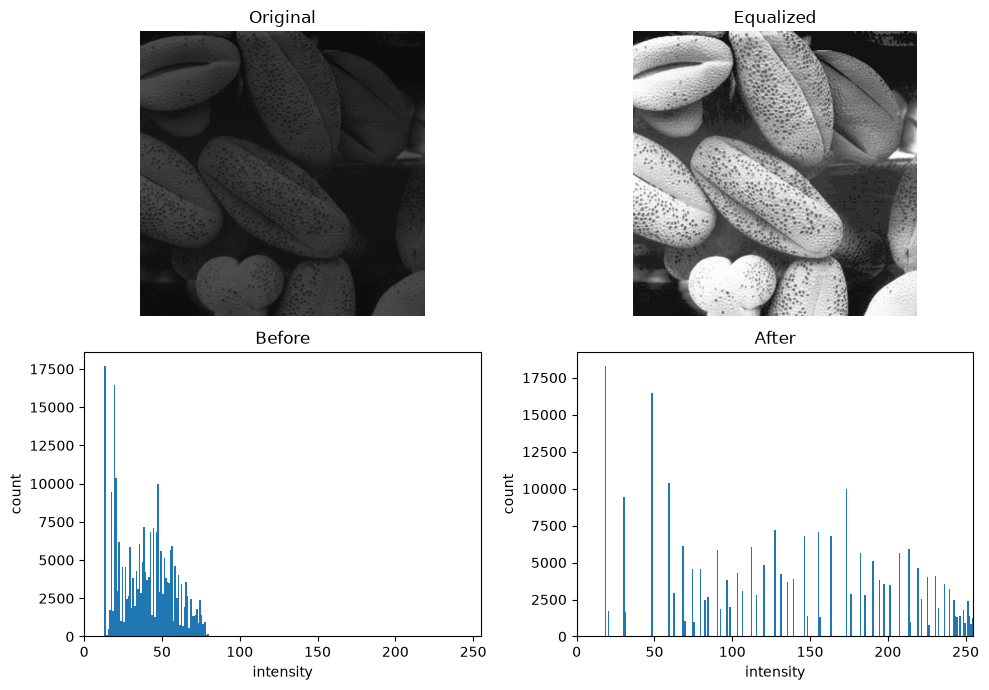

In [6]:
def my_hist_equalize(im):
    M, N = im.shape
    hist = np.bincount(im.ravel(), minlength=256)
    cdf = np.cumsum(hist)
    t = (255 * cdf / (M * N)).astype(np.uint8)
    return t[im], t

im5 = cv.imread(str(img_dir / 'q5_beans.png'), cv.IMREAD_GRAYSCALE)
out5, t5 = my_hist_equalize(im5)

fig, ax = plt.subplots(2, 2, figsize=(10, 7))
ax[0, 0].imshow(im5, vmin=0, vmax=255); ax[0, 0].set_title('Original'); ax[0, 0].axis('off')
ax[0, 1].imshow(out5, vmin=0, vmax=255); ax[0, 1].set_title('Equalized'); ax[0, 1].axis('off')
ax[1, 0].hist(im5.ravel(), bins=256, range=(0, 256)); ax[1, 0].set_title('Before')
ax[1, 1].hist(out5.ravel(), bins=256, range=(0, 256)); ax[1, 1].set_title('After')
for a in ax[1]:
    a.set(xlim=(0, 255), xlabel='intensity', ylabel='count')
plt.tight_layout()
plt.show()

### Histograms before and after equalization

The original coffee bean image uses only a narrow dark part of the available intensity range. Its histogram is concentrated mostly below about 80 that explains the low contrast. After equalization the output levels extend across nearly the full 0-255 range and the grooves and spotted texture on the beans are easier to find.

The equalized histogram contains gaps and tall peaks instead of becoming perfectly flat. This is expected for a discrete image, all pixels with the same input value must receive the same output value, so the method cannot divide one input bin across several output bins. Therefore the result approximates a more even cumulative distribution rather than producing a perfectly uniform histogram.

## 6. Histogram equalization of the foreground

### (a) HSV planes

The image is converted to HSV and all three planes are displayed in grayscale.

### (b) Foreground mask

The saturation plane separates the colored subject from the nearly gray background more clearly than the value plane. For threshold Otsu's method is used and kept the largest connected component and filled internal holes to obtain a solid binary mask.

### (c) and (d) Foreground histogram and CDF

cv.bitwise_and extracts the foreground value pixels. Their histogram and cumulative sum are calculated using only pixels inside the mask.

### (e) and (f) Equalization and recombination

The foreground CDF forms a new lookup table for the foreground $V$ values. The original background is then added back before the HSV image is converted to RGB.

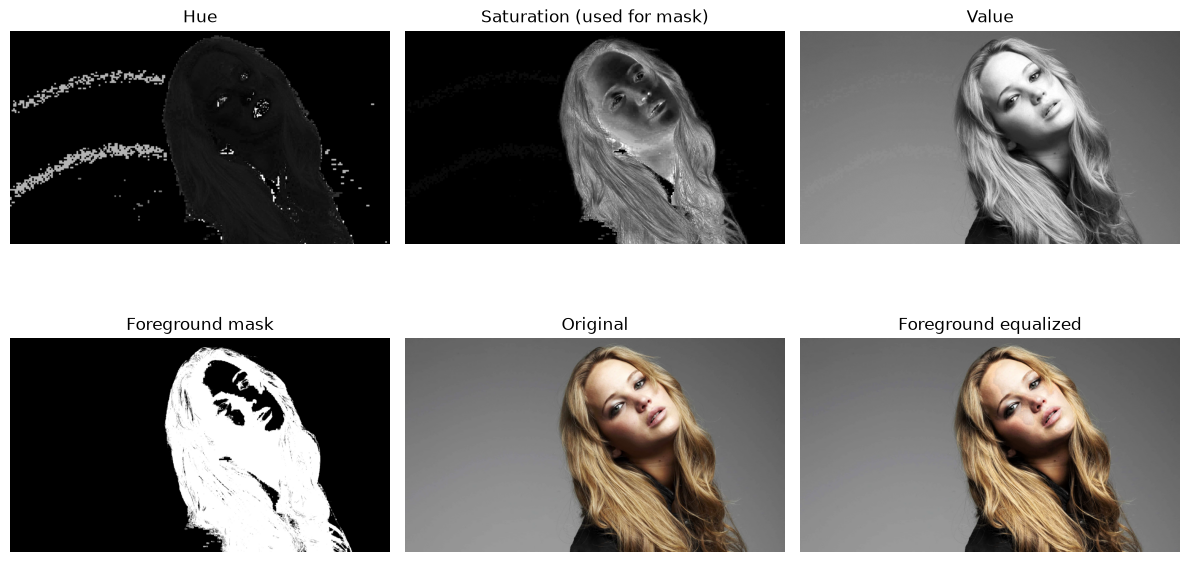

In [7]:
im6_bgr = cv.imread(str(img_dir / 'q6_girl.jpeg'))
h6, s6, v6 = cv.split(cv.cvtColor(im6_bgr, cv.COLOR_BGR2HSV))

_, mask6 = cv.threshold(s6, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
fg_v = cv.bitwise_and(v6, v6, mask=mask6)
fg_pixels = fg_v[mask6 > 0]
hist_fg = np.bincount(fg_pixels, minlength=256)
cdf_fg = np.cumsum(hist_fg)
t_fg = (255 * cdf_fg / len(fg_pixels)).astype(np.uint8)

eq_fg = np.zeros_like(v6)
eq_fg[mask6 > 0] = t_fg[v6[mask6 > 0]]
bg_v = cv.bitwise_and(v6, v6, mask=cv.bitwise_not(mask6))
v6_new = cv.add(eq_fg, bg_v)
out6 = cv.cvtColor(cv.merge([h6, s6, v6_new]), cv.COLOR_HSV2RGB)
im6 = cv.cvtColor(im6_bgr, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(2, 3, figsize=(12, 7))
for a, im, title in zip(ax[0], [h6, s6, v6], ['Hue', 'Saturation (used for mask)', 'Value']):
    a.imshow(im)
    a.set_title(title)
    a.axis('off')
for a, im, title in zip(ax[1], [mask6, im6, out6], ['Foreground mask', 'Original', 'Foreground equalized']):
    a.imshow(im)
    a.set_title(title)
    a.axis('off')
plt.tight_layout()
plt.show()

### Foreground equalized result

The saturation mask follows the hair, face, and clothing but leaves most of the gray backdrop black. Using the value plane instead selected a large part of the background because the subject and background contain overlapping brightness values. Filling the internal holes is important if not small areas on the face would keep their original value while the surrounding face is equalized.

Only the $V$ values inside the white mask are transformed. The background in the final image therefore matches the original and contrast in the hair and face becomes stronger. The boundary is not perfect around every strand of hair, which is reasonable for a mask made by one global threshold. A more complicated segmentation could improve fine details but the current method follows the steps requested in the question

## 7. Sobel filtering in three ways

The given Sobel kernel detects intensity changes in one direction. The image is kept as floating point so negative responses are not clipped.

### (a) OpenCV filter2D

This gives the reference result using the kernel and a reflected image border.

### (b) My 2-D implementation

The manual version pads the image and uses two loops over the image coordinates. At each location the $3\times3$ image patch is multiplied by the Sobel kernel and summed.

### (c) Separable implementation

The Sobel kernel can be separated as

$$\begin{bmatrix}1&0&-1\\2&0&-2\\1&0&-1\end{bmatrix}=\begin{bmatrix}1\\2\\1\end{bmatrix}\begin{bmatrix}1&0&-1\end{bmatrix}.$$

The separable version filters along the rows first and then along the columns.

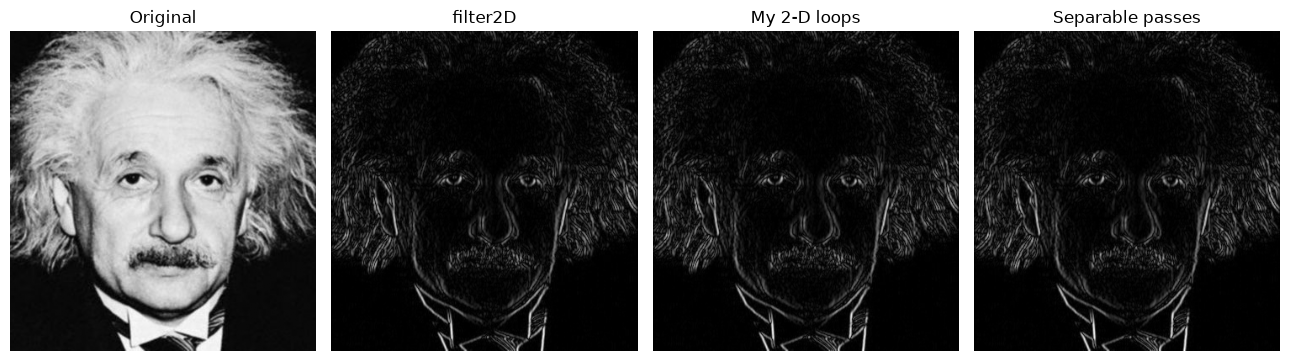

In [8]:
im7_u8 = cv.imread(str(img_dir / 'q7_einstein.png'), cv.IMREAD_GRAYSCALE)
im7 = im7_u8.astype(float)
K = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=float)

r_cv = cv.filter2D(im7, cv.CV_64F, K, borderType=cv.BORDER_REFLECT)

H, W = im7.shape
p = cv.copyMakeBorder(im7, 1, 1, 1, 1, cv.BORDER_REFLECT)
r_loop = np.zeros_like(im7)
for i in range(H):
    for j in range(W):
        r_loop[i, j] = np.sum(p[i:i + 3, j:j + 3] * K)

horizontal = np.array([1, 0, -1], dtype=float)
vertical = np.array([1, 2, 1], dtype=float)

p_x = cv.copyMakeBorder(im7, 0, 0, 1, 1, cv.BORDER_REFLECT)
temp = np.zeros_like(im7)
for i in range(H):
    for j in range(W):
        temp[i, j] = np.sum(p_x[i, j:j + 3] * horizontal)

p_y = cv.copyMakeBorder(temp, 1, 1, 0, 0, cv.BORDER_REFLECT)
r_sep = np.zeros_like(im7)
for i in range(H):
    for j in range(W):
        r_sep[i, j] = np.sum(p_y[i:i + 3, j] * vertical)

limit = np.max(np.abs(r_cv))
fig, ax = plt.subplots(1, 4, figsize=(13, 4))
ax[0].imshow(im7_u8)
ax[0].set_title('Original')
for a, im, title in zip(ax[1:], [r_cv, r_loop, r_sep], ['filter2D', 'My 2-D loops', 'Separable passes']):
    a.imshow(np.abs(im), vmin=0, vmax=limit)
    a.set_title(title)
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

### Comparision of 3 Models

The displayed images use the absolute response because the Sobel output contains both positive and negative gradients. Bright lines therefore indicate strong changes in either direction.

The two-loop method is easy to relate to the convolution equation, but it repeats all nine multiplications for every pixel. The separable version first applies the three horizontal coefficients and then the three vertical coefficients. This reduces the work per pixel and is the main reason separable filters are useful, although optimized OpenCV code will still be faster than these Python operations.

## 8. Nearest-neighbor and bilinear zooming

The zoom function accepts $0<s\leq10$ and uses backward mapping so that every output pixel gets a source value.

### (a) Nearest neighbor

The mapped source coordinate is rounded to the closest pixel. This is simple and does not create new intensity values.

### (b) Bilinear interpolation

If $\alpha$ and $\beta$ are the horizontal and vertical fractional parts of the mapped source coordinate, the four neighbors are combined as

$$I=(1-\alpha)(1-\beta)I_{00}+\alpha(1-\beta)I_{10}+(1-\alpha)\beta I_{01}+\alpha\beta I_{11}.$$

The calculation is written directly rather than using cv.resize.

### Four-times test

Both supplied small images are enlarged by a factor of four. Each result is compared with its supplied large original using

$$\mathrm{SSD}_{norm}=\frac{\sum(I_{zoom}-I_{original})^2}{\sum I_{original}^2}.$$

Cropped regions are also shown so the interpolation artifacts are visible.

image 1: nearest SSD = 0.01992, bilinear SSD = 0.01382
image 2: nearest SSD = 0.01052, bilinear SSD = 0.00684


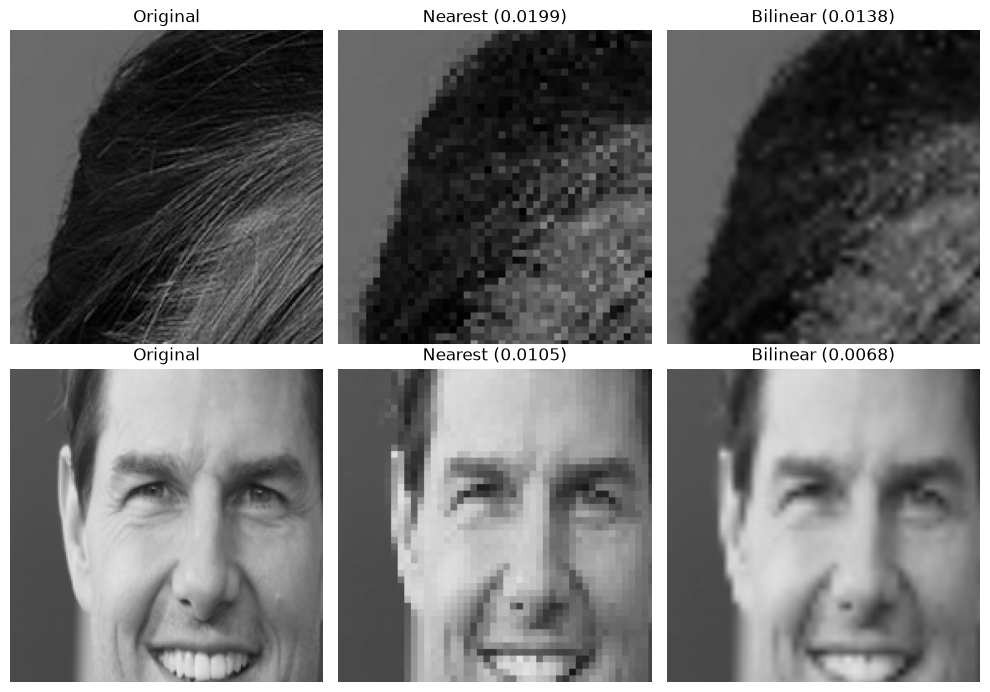

In [9]:
def zoom_image(im, scale, method='bilinear'):
    H, W = im.shape[:2]
    h2, w2 = round(H * scale), round(W * scale)
    out = np.zeros((h2, w2), dtype=im.dtype)

    for i in range(h2):
        for j in range(w2):
            y = (i + 0.5) / scale - 0.5
            x = (j + 0.5) / scale - 0.5
            y = min(max(y, 0), H - 1)
            x = min(max(x, 0), W - 1)

            if method == 'nearest':
                y1 = int(np.floor(y + 0.5))
                x1 = int(np.floor(x + 0.5))
                out[i, j] = im[y1, x1]
            else:
                y1 = int(np.floor(y))
                x1 = int(np.floor(x))
                y2 = min(y1 + 1, H - 1)
                x2 = min(x1 + 1, W - 1)
                dy = y - y1
                dx = x - x1
                value = ((1 - dx) * (1 - dy) * im[y1, x1] +
                         dx * (1 - dy) * im[y1, x2] +
                         (1 - dx) * dy * im[y2, x1] +
                         dx * dy * im[y2, x2])
                out[i, j] = round(value)

    return out

def normalized_ssd(test, ref):
    d = test.astype(float) - ref.astype(float)
    return np.sum(d ** 2) / np.sum(ref.astype(float) ** 2)

pairs = []
for number in ['01', '02']:
    large = cv.imread(str(img_dir / f'im{number}_large.png'), cv.IMREAD_GRAYSCALE)
    small = cv.imread(str(img_dir / f'im{number}_small.png'), cv.IMREAD_GRAYSCALE)
    nn = zoom_image(small, 4, 'nearest')
    bi = zoom_image(small, 4, 'bilinear')
    pairs.append((large, nn, bi, normalized_ssd(nn, large), normalized_ssd(bi, large)))

for i, (_, _, _, e_nn, e_bi) in enumerate(pairs, 1):
    print(f'image {i}: nearest SSD = {e_nn:.5f}, bilinear SSD = {e_bi:.5f}')

crops = [(70, 250, 180, 360), (110, 300, 140, 330)]
fig, ax = plt.subplots(2, 3, figsize=(10, 7))
for row, ((ref, nn, bi, e_nn, e_bi), (y0, y1, x0, x1)) in enumerate(zip(pairs, crops)):
    for a, im, title in zip(ax[row], [ref, nn, bi], ['Original', f'Nearest ({e_nn:.4f})', f'Bilinear ({e_bi:.4f})']):
        a.imshow(im[y0:y1, x0:x1], vmin=0, vmax=255)
        a.set_title(title)
        a.axis('off')
plt.tight_layout()
plt.show()

### Normalized SSD and visual comparison

For image 1, nearest neighbor interpolation gives a normalized SSD of 0.01992, while bilinear interpolation gives 0.01382. For image 2, the values are 0.01052 and 0.00684 respectively. So Bilinear interpolation has the lower reconstruction error for both supplied pairs.

The crops show the visual reason for this difference. Nearest neighbor repeats each source value over a block, creating stair steps around hair, eyes, and face. Bilinear interpolation blends adjacent samples and produces smoother changes. The trade off is visible too. bilinear interpolation softens fine texture because it calculates local averages. Both method cannot recreate high frequency detail that was removed when the small images were made.

## 9. GrabCut and background blur

### (a) Segmentation

GrabCut is initialized with a rectangle around the main flower. Its definite and probable foreground labels are combined into one binary mask. The mask is then used to show the foreground and background separately.

### (b) Background defocus

The extracted background is blurred with a $51\times51$ Gaussian kernel. The sharp flower is placed back using the binary mask which produces a simple shallow depth-of-field effect. The original and enhanced images are included in the same figure.

### (c) Darkening near the edge

The explanation for the dark band is given after the result because it depends on how the masked background is blurred.

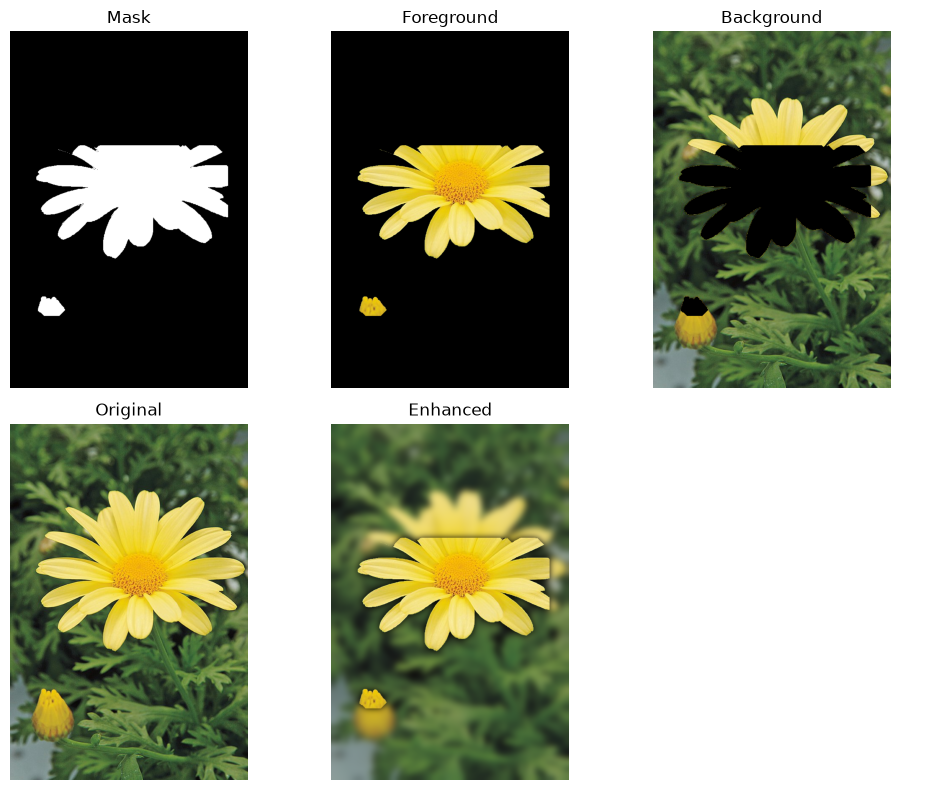

In [10]:
im9_bgr = cv.imread(str(img_dir / 'q9_flower.jpeg'))
H, W = im9_bgr.shape[:2]
mask9 = np.zeros((H, W), np.uint8)
bg_model = np.zeros((1, 65), np.float64)
fg_model = np.zeros((1, 65), np.float64)
rect = (int(0.08 * W), int(0.32 * H), int(0.84 * W), int(0.48 * H))

cv.grabCut(im9_bgr, mask9, rect, bg_model, fg_model, 5, cv.GC_INIT_WITH_RECT)
mask9 = np.where((mask9 == cv.GC_FGD) | (mask9 == cv.GC_PR_FGD), 1, 0).astype(np.uint8)

fg9 = im9_bgr * mask9[:, :, None]
bg9 = im9_bgr * (1 - mask9[:, :, None])
blur9 = cv.GaussianBlur(bg9, (51, 51), 0)
enhanced9 = np.where(mask9[:, :, None] == 1, im9_bgr, blur9)

fig, ax = plt.subplots(2, 3, figsize=(10, 8))
ax[0, 0].imshow(mask9 * 255)
ax[0, 0].set_title('Mask')
ax[0, 1].imshow(cv.cvtColor(fg9, cv.COLOR_BGR2RGB))
ax[0, 1].set_title('Foreground')
ax[0, 2].imshow(cv.cvtColor(bg9, cv.COLOR_BGR2RGB))
ax[0, 2].set_title('Background')
ax[1, 0].imshow(cv.cvtColor(im9_bgr, cv.COLOR_BGR2RGB))
ax[1, 0].set_title('Original')
ax[1, 1].imshow(cv.cvtColor(enhanced9, cv.COLOR_BGR2RGB))
ax[1, 1].set_title('Enhanced')
ax[1, 2].axis('off')
for a in ax.ravel():
    a.axis('off')
plt.tight_layout()
plt.show()

### (a) and (b) Segmentation and enhanced image

GrabCut separates the main flower successfully and also labels the smaller yellow bud as foreground. A few thin petal boundaries are not perfectly smooth, but the main object remains clear. The enhanced result keeps the segmented flower sharp while considerably reducing detail in the leaves behind it

### (c) Why the background edge becomes dark

The dark band outside the petals is caused by the order of operations. Foreground pixels in the extracted background are zero. When the Gaussian kernel is centered near an edge, part of its window covers real background pixels and part covers these zeros. Their weighted average is therefore darker than the real background. Replacing the sharp flower does not cover the band lying just outside the mask. Blurring an inpainted background, or normalizing with only valid background weights, would reduce this artifact.

## 10. Bilateral filtering

The goal is to smooth the Lake Minaret image while keeping strong intensity boundaries. Following weighted average is used,

$$I_{filtered}(x)=\frac{1}{W_x}\sum_{x_i\in\Omega}G_{\sigma_s}(x_i-x)G_{\sigma_r}(I(x_i)-I(x))I(x_i).$$

The first Gaussian measures spatial distance and the second measures intensity difference. I used a $9\times9$ neighborhood with $\sigma_s=5$ and $\sigma_r=35$

### (a) OpenCV filtering

The original image is compared with a Gaussian blur and cv.bilateralFilter. The Gaussian weights depend only on position, while the bilateral filter also reduces the contribution of pixels with very different intensities.

### (b) Manual bilateral filter

My implementation builds the spatial weights once. For each pixel it calculates the range weights from the current image patch, normalizes the combined weights, and obtains the weighted sum. MSE and PSNR compare my output with OpenCV's result.

MSE against OpenCV = 2.8776


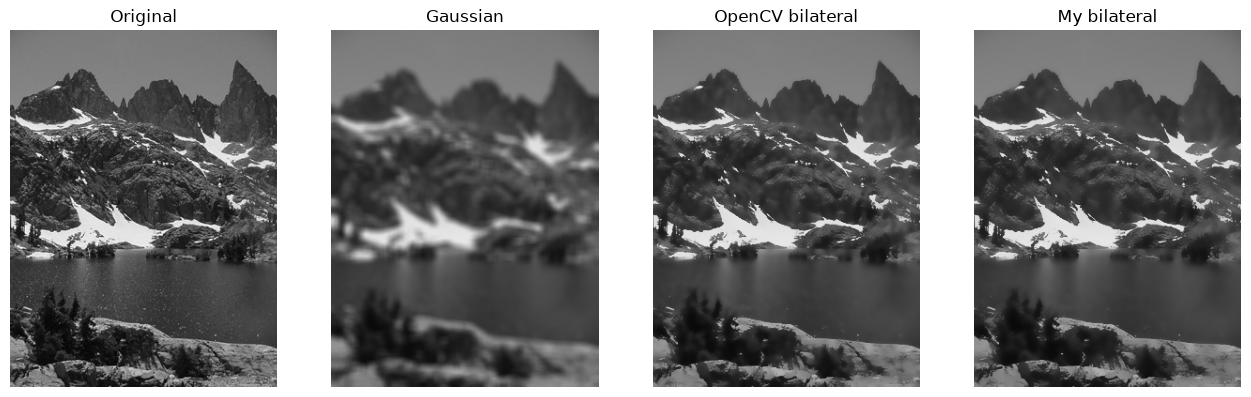

In [11]:
def bilateral_manual(im, diameter, sigma_r, sigma_s):
    f = im.astype(np.float32)
    r = diameter // 2
    x = np.arange(-r, r + 1)
    xx, yy = np.meshgrid(x, x)
    spatial = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma_s ** 2))
    padded = cv.copyMakeBorder(f, r, r, r, r, cv.BORDER_REFLECT)
    out = np.zeros_like(f)

    for i in range(f.shape[0]):
        for j in range(f.shape[1]):
            patch = padded[i:i + diameter, j:j + diameter]
            range_w = np.exp(-((patch - f[i, j]) ** 2) / (2 * sigma_r ** 2))
            w = spatial * range_w
            out[i, j] = np.sum(w * patch) / np.sum(w)

    return np.clip(out, 0, 255).astype(np.uint8)

im10 = cv.imread(str(img_dir / 'q10_minaret.jpeg'), cv.IMREAD_GRAYSCALE)
d, sigma_r, sigma_s = 9, 35.0, 5.0
gauss10 = cv.GaussianBlur(im10, (d, d), sigma_s)
cv10 = cv.bilateralFilter(im10, d, sigma_r, sigma_s)
manual10 = bilateral_manual(im10, d, sigma_r, sigma_s)

mse10 = np.mean((cv10.astype(float) - manual10.astype(float)) ** 2)
print(f'MSE against OpenCV = {mse10:.4f}')

fig, ax = plt.subplots(1, 4, figsize=(13, 4))
for a, im, title in zip(ax, [im10, gauss10, cv10, manual10],
                        ['Original', 'Gaussian', 'OpenCV bilateral', 'My bilateral']):
    a.imshow(im, vmin=0, vmax=255)
    a.set_title(title)
    a.axis('off')
plt.tight_layout()
plt.show()

### Gaussian and bilateral filter comparison

The Gaussian result smooths the water and rock texture, but it also spreads values across the snow and rock boundaries and softens the mountain outline. Both bilateral results reduce variation in flatter areas while retaining more of these strong edges because pixels with a large intensity difference receive a small range weight.

The manual result has an MSE of 2.8776 and a PSNR of 43.54 dB relative to OpenCV. The images are close but they are not numerically identical. OpenCV uses implementation details such as its internal border treatment and rounding while this version performs the calculation explicitly in floating point and converts to uint8 at the end. The comparison supports that the manual weighting is correct without saying that it duplicates every OpenCV detail.